In [154]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as sp
from scipy.signal import find_peaks

In [185]:
# Fitting functions

def sine(t,A,omega):
    return A*np.sin(omega*t)
def exponential(t,A,T2):
    return A*np.exp(-t/T2)

[2.48] [7.47]
[9.36063115 0.62865315] [0.21557776 0.00363387]


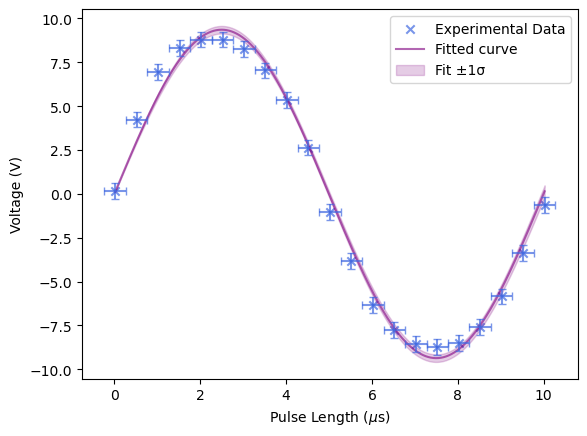

In [224]:
# FID Amp vs Pulse Length good
pulse_len0, amp0 = np.loadtxt('../Data/FID_Amplitude_vs_Pulse_Length_raw.txt',delimiter='\t',unpack=True,skiprows=2)


for i in range(len(pulse_len0)):
    if i > 9:
        amp0[i] = -amp0[i]

params, covariance = sp.curve_fit(sine,pulse_len0,amp0,p0=[max(amp0),2*np.pi/10])
t = np.linspace(pulse_len0[0],pulse_len0[-1],1000)

peaks,_ = find_peaks(sine(t,*params))
troughs,_ = find_peaks(-sine(t,*params))

print(peaks/100,troughs/100)

y_err = np.sqrt(0.01**2+0.05**2)*max(amp0)
x_err = 0.25

# derivatives
A, omega = params
dy_dA = np.sin(omega*t)
dy_domega = A * t * np.cos(omega*t)

# covariance matrix
C = covariance

# error propagation
y_fit_err = np.sqrt(
    dy_dA**2*C[0,0] + dy_domega**2*C[1,1] + 2*dy_dA*dy_domega*C[0,1])

std_err = np.sqrt(np.diag(covariance))
print(params,std_err)

plt.scatter(pulse_len0,amp0,marker='x',color='royalblue',label="Experimental Data",alpha=0.7)
plt.plot(t,sine(t,*params),"-",color='purple',label="Fitted curve",alpha=0.6)
plt.errorbar(pulse_len0,amp0,xerr=x_err,yerr=y_err,color='royalblue',capsize=3,linestyle=' ',alpha=0.7)
plt.fill_between(
    t, sine(t,*params)-y_fit_err,
    sine(t,*params)+y_fit_err,
    color='purple', alpha=0.2, label='Fit ±1σ'
)

plt.xlabel(r'Pulse Length ($\mu$s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.savefig("../Figures/goodpulselength")
plt.show()

[2.52] [7.59]
[0.98473847 0.61844111] [0.02563994 0.00398326]


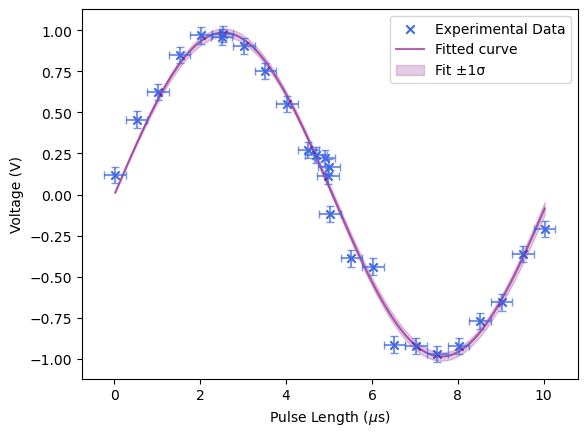

In [225]:
# FID Amp vs Pulse Length bad
pulse_len1, amp1 = np.loadtxt('../Data/FID_Amplitude_vs_RF_time_Trial1_raw.txt',delimiter='\t',unpack=True,skiprows=2)

for i in range(len(pulse_len1)):
    if pulse_len1[i] > 5:
        amp1[i] = -amp1[i]

params, covariance = sp.curve_fit(sine,pulse_len1,amp1,p0=[max(amp1),2*np.pi/10])
t = np.linspace(pulse_len1[0],pulse_len1[-1],1000)

peaks,_ = find_peaks(sine(t,*params))
troughs,_ = find_peaks(-sine(t,*params))

print(peaks/100,troughs/100)

y_err = np.sqrt(0.01**2+0.05**2)*max(amp1)
x_err = 0.25

A, omega = params
dy_dA = np.sin(omega*t)
dy_domega = A * t * np.cos(omega*t)

C = covariance

y_fit_err = np.sqrt(
    dy_dA**2*C[0,0] + dy_domega**2*C[1,1] + 2*dy_dA*dy_domega*C[0,1])

std_err = np.sqrt(np.diag(covariance))
print(params,std_err)

plt.scatter(pulse_len1,amp1,marker='x',color='royalblue',label='Experimental Data')
plt.xlabel(r'Pulse Length ($\mu$s)')
plt.plot(t,sine(t,*params),"-",color='purple',label="Fitted curve",alpha=0.6)
plt.errorbar(pulse_len1,amp1,xerr=x_err,yerr=y_err,color='royalblue',capsize=3,linestyle=' ',alpha=0.7)
plt.fill_between(
    t, sine(t,*params)-y_fit_err,
    sine(t,*params)+y_fit_err,
    color='purple', alpha=0.2, label='Fit ±1σ'
)
plt.ylabel('Voltage (V)')
plt.legend()
plt.savefig("../Figures/badpulselength")
plt.show()

[372.80100899   3.02644611] [21.14288632  0.04037695]


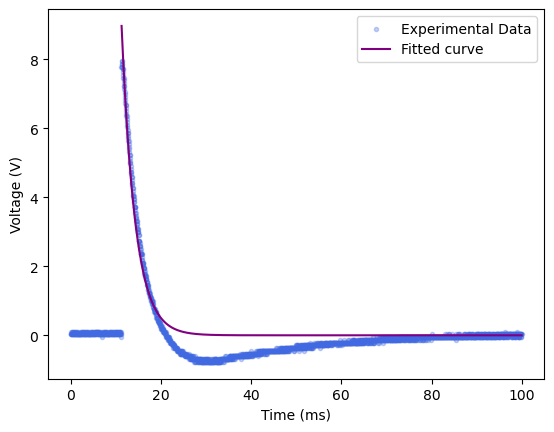

In [216]:
# FID vs Time bad
time0, FID_amp0 = np.loadtxt('../Data/FID_vs_time.txt',delimiter='\t',unpack=True,skiprows=8)



peak,_ = find_peaks(FID_amp0,height=7.5)
peak = peak[0]
t = np.linspace(time0[peak],time0[-1],1000)

time_sub = time0[peak:]
amp_sub = FID_amp0[peak:]

params, covariance = sp.curve_fit(exponential,time_sub,amp_sub,p0=[max(FID_amp0),4])
std_err = np.sqrt(np.diag(covariance))
print(params,std_err)


plt.scatter(time0,FID_amp0,marker='.',color='royalblue',alpha=0.3,label='Experimental Data')
plt.plot(t,exponential(t,*params),color='purple',label="Fitted curve",alpha=1)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.savefig("../Figures/badtime")
plt.show()

[1.52456227e+06 3.50513919e+00] [1.21456775e+05 1.88804775e-02]


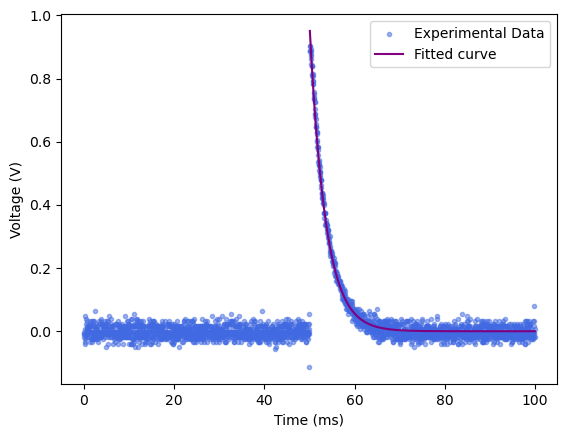

In [215]:
# FID vs Time good

time1, FID_amp1 = np.loadtxt('../Data/FID_vs_time_with_dip.txt',delimiter='\t',unpack=True,skiprows=8)

peak,_ = find_peaks(FID_amp1,height=0.7)
peak = peak[0]
t = np.linspace(time1[peak],time1[-1],1000)

time_sub = time1[peak:]
amp_sub = FID_amp1[peak:]

params, covariance = sp.curve_fit(exponential,time_sub,amp_sub,p0=[max(FID_amp1),4])

std_err = np.sqrt(np.diag(covariance))
print(params,std_err)

plt.scatter(time1,FID_amp1,marker='.',color='royalblue',alpha=0.5,label='Experimental Data')
plt.plot(t,exponential(t,*params),color='purple',label="Fitted curve",alpha=1)
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.savefig("../Figures/goodtime")
plt.show()